#### Imports

In [ ]:
import importlib
import pandas as pd
import numpy as np
import random
import copy

import matplotlib.pyplot as plt

from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.gaussian_process import GaussianProcessRegressor

import globals
import utils

np.set_printoptions(precision=4, suppress=True, linewidth=np.inf, threshold=np.inf)

pd.set_option("display.width", 1000)
pd.set_option("display.max_columns", None)

seed = 42
random.seed(seed)
np.random.seed(seed)

In [302]:
importlib.reload(globals)
importlib.reload(utils)

<module 'utils' from 'c:\\Users\\Matteo\\Desktop\\Scuola\\MastersThesis\\Masters_Thesis\\utils.py'>

In [303]:
param_names, function_names = utils.inspect_metadata(globals.CURRENT_TRAIN_FILE)

Keys in train_file: ['I0', 'LUTdata', 'LUTheader', 'dynamic', 'static', 'wvl']

Attributes in LUTheader (inputs):
  varnames: O3STR,H2OSTR,VIS,G,ASTMX,SSA,PARM2,OBSZEN,PARM1

Attributes in train_file (outputs):
  RTMname: MODTRAN6
  inputmode: Latin hypercube
  lut_package_date: 10-Apr-2025
  opmode: Transfer Functions
  outnames: Lp0,Edir0,Edif0,S,tdir,tdif
  sensor: Empty(dtype=dtype('O'))

LUTheader shape: (500, 9)
LUTdata shape: (500, 25230)
wvl shape: (1, 4205)


In [304]:
X, Y, wavelengths = utils.load_train_h5(globals.CURRENT_TRAIN_FILE)
wavelengths = wavelengths.squeeze()
Y_resh = Y.reshape(-1, Y.shape[1] // len(wavelengths), len(wavelengths))

X_tr, X_val, X_test, Y_tr, Y_val, Y_test = utils.train_val_test_split(X, Y_resh, wavelengths, verbose=True)

X shape: (500, 9)
Y shape: (500, 6, 4205)
wavelengths shape: (4205,)

X_tr shape: (400, 9)
X_val shape: (50, 9)
X_test shape: (50, 9)

Y_tr shape: (400, 6, 4205)
Y_val shape: (50, 6, 4205)
Y_test shape: (50, 6, 4205)


#### Gaussian Processes on each Wavelength (no PCA)

GPs deal with the high number of bands with PCA, reducing them to just 10 Principal Components. However, PCA lacks interpretability. The following section investigates a method to avoid using dimensionality reduction while still keeping computational times feasible.

In [ ]:
def create_adaptive_windows(complexity, n_windows):
    """
    Create spectral windows with approximately equal spectral complexity.

    Parameters
    ----------
    wavelengths: ndarray
        Wavelength grid.

    complexity: ndarray
        Spectral complexity measure.

    n_windows: int
        Number of windows.

    Returns
    -------
    windows: list of ndarray
        Indices for each spectral window.
    """

    cumulative = np.cumsum(complexity)

    # normalize cumulative complexity
    cumulative = cumulative / cumulative[-1]

    # desired complexity fractions
    targets = np.linspace(0, 1, n_windows + 1)

    boundaries = []

    for t in targets:
        idx = np.argmin(np.abs(cumulative - t))
        boundaries.append(idx)

    # remove duplicates (can happen in flat regions)
    boundaries = np.unique(boundaries)

    windows = []
    for i in range(len(boundaries)-1):
        start = boundaries[i]
        end = boundaries[i+1]

        if end > start:
            windows.append(np.arange(start, end))

    return windows


def spectra_to_piecewise(Y, spectral_windows, degree, wavelengths):
    """
    Parameters
    ----------
    Y: (samples, functions, wavelengths)

    spectral_windows:
        list of length n_functions.
        spectral_windows[f] is the list of windows for function f.

    Returns
    -------
    coeffs:
        (samples, functions, n_coeffs)

    Assumes every function produces the same number of coefficients.

    Uses a Taylor (power series) basis: 1, x, x^2, ..., x^degree,
    where x is the wavelength within each window centered and scaled
    (x = (wl - wl_center) / wl_scale). Coefficients are fit via
    least squares, equivalent to a Taylor expansion around the
    window's center wavelength.
    """

    if len(spectral_windows) > 0 and isinstance(spectral_windows[0], np.ndarray):
        spectral_windows = [spectral_windows for _ in range(Y.shape[1])]

    coeffs_functions = []
    for f in range(globals.N_FUNCTIONS):
        coeffs_windows = []

        for idx in spectral_windows[f]:
            wl = wavelengths[idx]

            # center on the window midpoint (natural Taylor expansion point)
            # and scale for numerical conditioning of the power basis.
            x = (wl - wl.mean()) / wl.std()

            # power/Taylor basis: [1, x, x^2, ..., x^degree]
            A = np.vander(x, degree + 1, increasing=True)
            y = Y[:, f, idx]
            c = np.linalg.lstsq(A, y.T, rcond=None)[0].T
            coeffs_windows.append(c)

        coeffs_windows = np.concatenate(coeffs_windows, axis=1)
        coeffs_functions.append(coeffs_windows)

    coeffs_functions = np.stack(coeffs_functions, axis=1)

    return coeffs_functions


def piecewise_to_spectrum(coefficients, spectral_windows, degree, wavelengths):
    """
    Reconstructs spectra from Taylor (power series) coefficients
    produced by spectra_to_piecewise.
    """

    if len(spectral_windows) > 0 and isinstance(spectral_windows[0], np.ndarray):
        spectral_windows = [spectral_windows for _ in range(globals.N)]

    squeeze = False

    if coefficients.ndim == 2:
        coefficients = coefficients[:, None, :]
        squeeze = True

    n_samples, n_functions, _ = coefficients.shape

    Y = np.zeros((n_samples, n_functions, len(wavelengths)))

    for f in range(n_functions):
        coeff_idx = 0

        for idx in spectral_windows[f]:
            wl = wavelengths[idx]
            x = (wl - wl.mean()) / wl.std()
            A = np.vander(x, degree + 1, increasing=True)
            coeff = coefficients[:, f, coeff_idx:coeff_idx+degree+1]
            Y[:, f, idx] = coeff @ A.T
            coeff_idx += degree + 1

    if squeeze:
        return Y[:, 0]

    return Y


def configure_parameters(Y, n_windows, wavelengths, verbose=True):
    spectral_windows = []
    for function_idx, name in enumerate(globals.function_names_plots):
        mean_spectrum = Y[:, function_idx, :].mean(axis=0)

        first_derivative = np.gradient(mean_spectrum)
        second_derivative = np.gradient(first_derivative)

        complexity = (
            np.abs(first_derivative)
            + 0.2*np.abs(second_derivative)
        )

        windows = create_adaptive_windows(complexity, n_windows=n_windows)
        spectral_windows.append(windows)

        if verbose:
            # for i, w in enumerate(windows):
            #   print(i, wavelengths[w[0]], wavelengths[w[-1]], len(w))

            plt.figure(figsize=(12,4))
            plt.plot(wavelengths, mean_spectrum)
            for w in windows:
                plt.axvline(wavelengths[w[0]], linestyle="--")
            plt.xlabel("Wavelength (nm)")
            plt.ylabel("Value")
            plt.title(name)
            plt.show()

    return spectral_windows

In [306]:
min_mre = 9999
min_mae = 9999
min_degree = 9999
min_window_number = 9999

for degree in range(2, 11):
    for n_windows in [7, 10, 20, 50, 100]:
        windows = configure_parameters(Y_val, n_windows, wavelengths, False)

        Y_test_coeff = spectra_to_piecewise(Y_val, windows, degree, wavelengths)
        Y_test_recon = np.zeros_like(Y_val)

        Y_test_recon = piecewise_to_spectrum(Y_test_coeff, windows, degree, wavelengths)

        mre_recon = utils.mre_score(Y_val, Y_test_recon, wavelengths, axis=None)
        mae_recon = utils.mae_score(Y_val, Y_test_recon, wavelengths, axis=None)

        print(f"{degree} | {n_windows} | MRE: {mre_recon:.4f} | MAE: {mae_recon:.4f}")

        if mre_recon < min_mre:
            min_mre = mre_recon
            min_mae = mae_recon
            min_degree = degree
            min_window_number = n_windows

print(f"\nBest result:\n\tMRE: {min_mre:.4f} | MAE: {min_mae:.4f} | Degree: {min_degree} | Window number: {min_window_number}")

2 | 7 | MRE: 1.2599 | MAE: 22.8913
2 | 10 | MRE: 1.0519 | MAE: 21.6443
2 | 20 | MRE: 0.6529 | MAE: 19.9824
2 | 50 | MRE: 0.2510 | MAE: 17.5857
2 | 100 | MRE: 0.1339 | MAE: 15.6200
3 | 7 | MRE: 0.7653 | MAE: 20.9748
3 | 10 | MRE: 0.6466 | MAE: 20.5356
3 | 20 | MRE: 0.4076 | MAE: 19.4810
3 | 50 | MRE: 0.1693 | MAE: 16.9566
3 | 100 | MRE: 0.0985 | MAE: 14.7536
4 | 7 | MRE: 0.5030 | MAE: 20.5028
4 | 10 | MRE: 0.4248 | MAE: 20.0792
4 | 20 | MRE: 0.2651 | MAE: 18.9438
4 | 50 | MRE: 0.1152 | MAE: 16.3257
4 | 100 | MRE: 0.0774 | MAE: 13.9554
5 | 7 | MRE: 0.2844 | MAE: 20.2688
5 | 10 | MRE: 0.2500 | MAE: 19.8696
5 | 20 | MRE: 0.1623 | MAE: 18.3132
5 | 50 | MRE: 0.0930 | MAE: 15.7055
5 | 100 | MRE: 0.0686 | MAE: 13.0452
6 | 7 | MRE: 0.2270 | MAE: 20.1894
6 | 10 | MRE: 0.2055 | MAE: 19.5708
6 | 20 | MRE: 0.1380 | MAE: 18.1182
6 | 50 | MRE: 0.0867 | MAE: 15.1968
6 | 100 | MRE: 0.0738 | MAE: 12.1610
7 | 7 | MRE: 0.1642 | MAE: 20.1240
7 | 10 | MRE: 0.1504 | MAE: 19.3904
7 | 20 | MRE: 0.1056 | MAE: 1

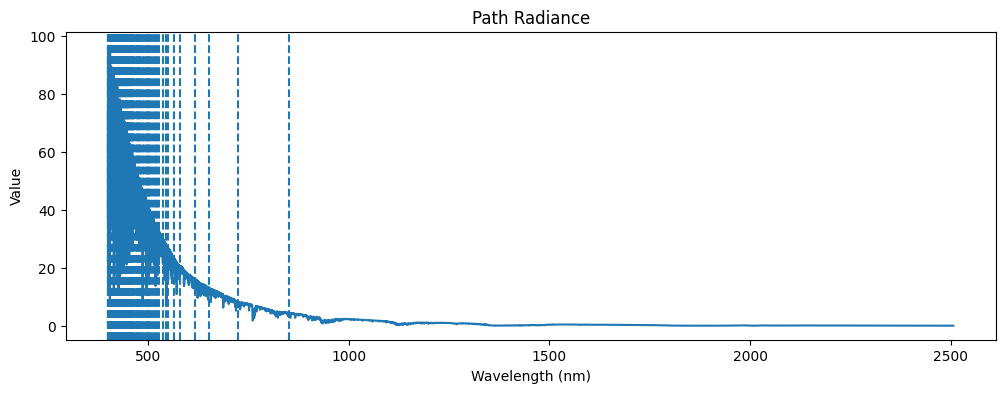

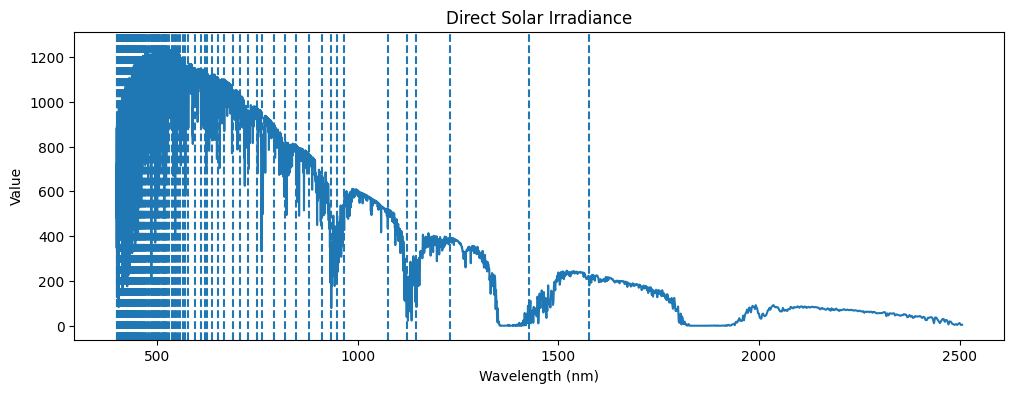

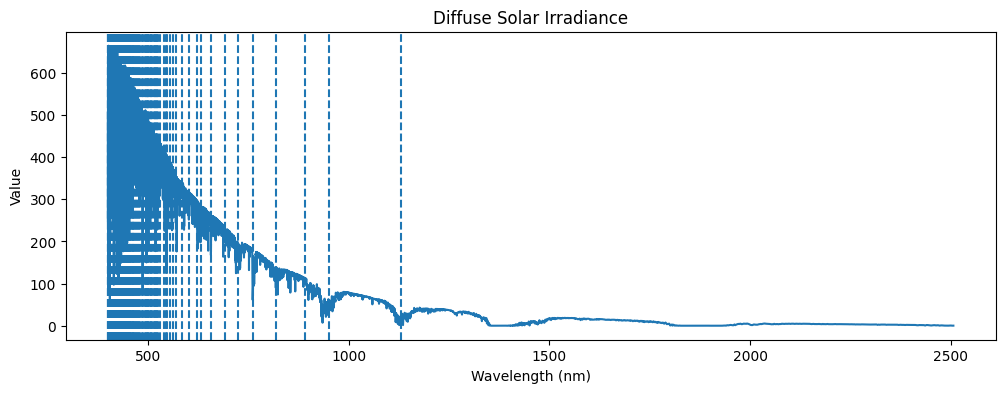

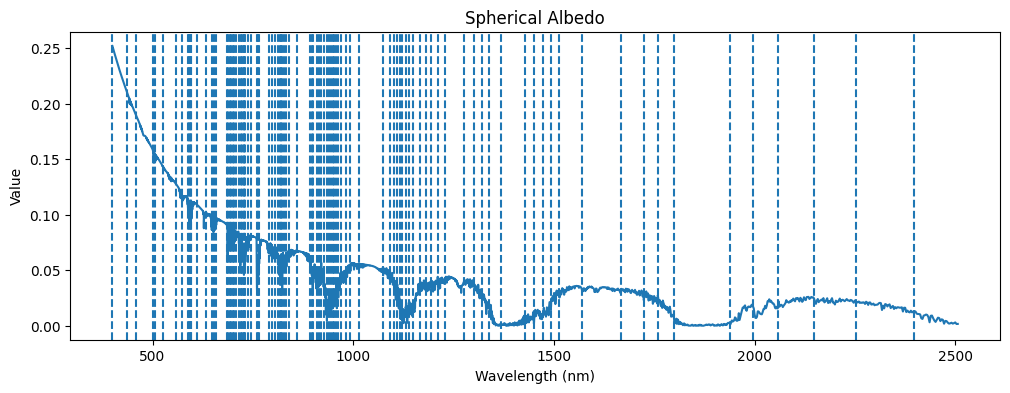

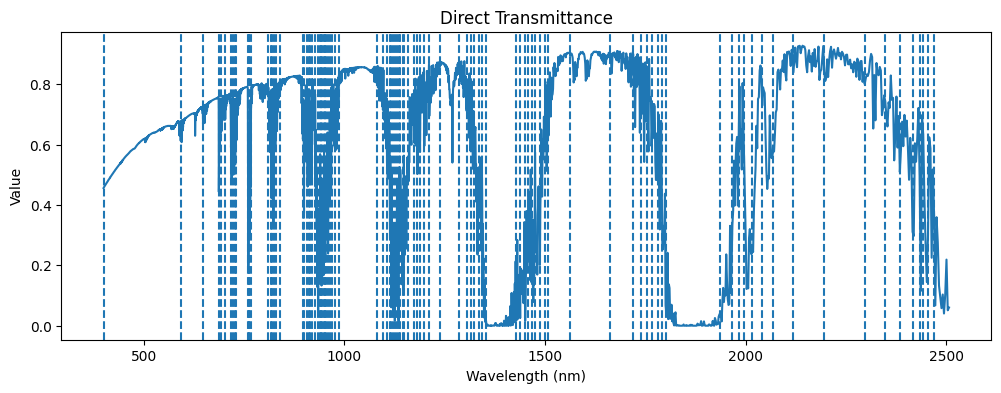

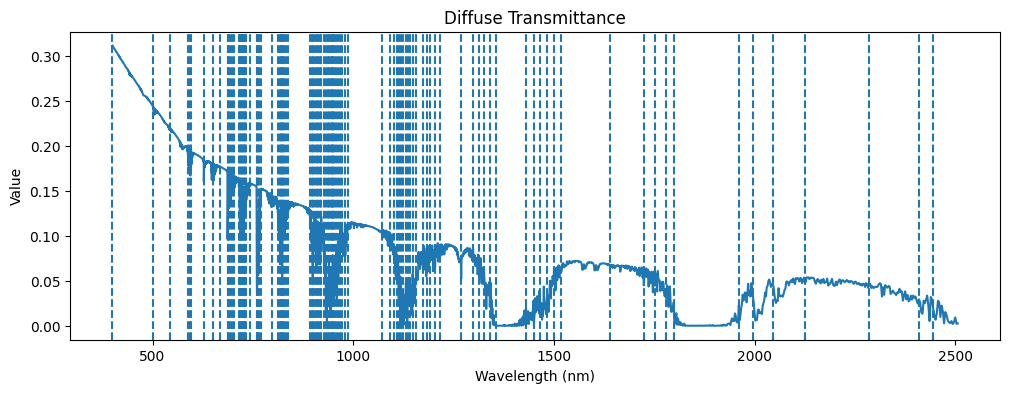

In [307]:
# ----- configuration -----
scale_type_piecewise = "minmax"
degree_piecewise = 5
n_windows_piecewise = 100

spectral_windows = configure_parameters(Y_val, n_windows_piecewise, wavelengths, True)

In [308]:
Y_tr_piecewise = spectra_to_piecewise(Y_tr, spectral_windows, degree_piecewise, wavelengths)
Y_val_piecewise = spectra_to_piecewise(Y_val, spectral_windows, degree_piecewise, wavelengths)
print("Piecewise coefficient shape training:", Y_tr_piecewise.shape)
print("Piecewise coefficient shape validation:", Y_val_piecewise.shape)

x_scaler_piecewise, X_tr_scaled_piecewise, X_val_scaled_piecewise = utils.scale_input_data(X_tr, X_val, scale_type=scale_type_piecewise)
y_scalers_piecewise, Y_tr_piecewise_scaled, Y_val_piecewise_scaled = utils.scale_output_data(Y_tr_piecewise, Y_val_piecewise, scale_type=scale_type_piecewise)

piecewise_kernel = (
    C(1.0, (1e-3, 1e3))
    * Matern(
        length_scale=np.ones(globals.N_INPUTS),
        length_scale_bounds=(1e-3, 1e3),
        nu=2.5
    )
    + WhiteKernel(1e-2, (1e-5, 1e1))
)

Piecewise coefficient shape training: (400, 6, 600)
Piecewise coefficient shape validation: (50, 6, 600)
---------- Scaling input data using minmax scaling... ----------
---------- Input data scaling completed. ----------

---------- Scaling output data using minmax scaling... ----------
---------- Output data scaling completed. ----------



In [309]:
gpr_list = []
for i in range(globals.N_FUNCTIONS):
    gpr = GaussianProcessRegressor(kernel=copy.deepcopy(piecewise_kernel), n_restarts_optimizer=0, random_state=42)
    gpr.fit(X_tr_scaled_piecewise, Y_tr_piecewise_scaled[:, i, :])
    print("Learned kernel:", gpr.kernel_)
    gpr_list.append(gpr)

Learned kernel: 1.58**2 * Matern(length_scale=[173, 22.2, 4.93, 7.69, 14, 16.2, 3.94, 8.38, 3.98], nu=2.5) + WhiteKernel(noise_level=3.77e-05)


c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 5 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  w

Learned kernel: 1.93**2 * Matern(length_scale=[292, 4.57, 6.66, 1e+03, 13.2, 1e+03, 3.2, 37.7, 4.66], nu=2.5) + WhiteKernel(noise_level=1e-05)


c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 7 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 8 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Learned kernel: 1.88**2 * Matern(length_scale=[236, 8.55, 4.15, 24.7, 12, 20.1, 4.15, 1e+03, 1e+03], nu=2.5) + WhiteKernel(noise_level=7.87e-05)
Learned kernel: 1.33**2 * Matern(length_scale=[332, 0.5, 3.44, 9.46, 5.6, 15, 9.74, 626, 214], nu=2.5) + WhiteKernel(noise_level=0.000818)


c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 5 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 6 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better valu

Learned kernel: 2.24**2 * Matern(length_scale=[192, 0.536, 9.17, 1e+03, 7.44, 1e+03, 1e+03, 16, 1e+03], nu=2.5) + WhiteKernel(noise_level=8.9e-05)
Learned kernel: 1.39**2 * Matern(length_scale=[125, 1.09, 4.01, 26.5, 4.89, 29, 10.6, 79.7, 245], nu=2.5) + WhiteKernel(noise_level=0.000492)


In [310]:
def validate_piecewise_taylor(gpr_list, X_scaled, y_scalers):
    coeff_pred = np.zeros_like(Y_val_piecewise)

    for f_idx in range(globals.N_FUNCTIONS):

        coeff_scaled = gpr_list[f_idx].predict(X_scaled)
        coeff = y_scalers[f_idx].inverse_transform(coeff_scaled)

        coeff_pred[:, f_idx, :] = coeff

    Y_pred = piecewise_to_spectrum(coeff_pred, spectral_windows, degree_piecewise, wavelengths)

    return Y_pred

Y_pred_val_piecewise = validate_piecewise_taylor(gpr_list, X_val_scaled_piecewise, y_scalers_piecewise)


mre_piecewise = utils.mre_score(Y_val, Y_pred_val_piecewise, wavelengths, axis=None)
mae_piecewise = utils.mae_score(Y_val, Y_pred_val_piecewise, wavelengths, axis=None)
print("Piecewise Taylor GP MRE:", mre_piecewise)
print("Piecewise Taylor GP MAE:", mae_piecewise)

Piecewise Taylor GP MRE: 0.06959969569768089
Piecewise Taylor GP MAE: 13.055971071309722
